In [10]:
%pip install -q pymssql pandas numpy scikit-learn matplotlib seaborn statsmodels python-dotenv

Note: you may need to restart the kernel to use updated packages.


## Setup

This notebook connects to the Azure SQL database. Create a `.env` file in this directory (`MachineLearning/ml-pipelines/.env`) with:

```
DB_SERVER=lunas-project-intex-sql.database.windows.net
DB_DATABASE=lunas-project-db
DB_USERNAME=sqladmin
DB_PASSWORD=<your-password>
```

# Visitation Outcome Predictor

Predict whether a home visitation will have a **favorable** outcome based on visit characteristics and resident history.

## 1. Problem Framing

**Business Problem:** Home visitations are critical for reintegration decisions at Lighthouse Philippines. Predicting visit outcomes helps social workers prioritize follow-ups and allocate resources.

**Target variable:** `favorable` — binary (1 = Favorable, 0 = Unfavorable/Needs Improvement/Inconclusive).

| Approach | Goal | Method |
|----------|------|--------|
| **Explanatory** | Understand *what drives* favorable outcomes | Logistic Regression (statsmodels) |
| **Predictive** | Classify favorable vs. not | GradientBoostingClassifier (sklearn Pipeline) |

## 2. Data Preparation & Exploration

In [11]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
SEED = 42
import pymssql
import re as _re

# ── Azure SQL connection ─────────────────────────────────────────────────────
from dotenv import load_dotenv, find_dotenv
import os
load_dotenv(find_dotenv())

SERVER = os.getenv('DB_SERVER')
DATABASE = os.getenv('DB_DATABASE')
USER = os.getenv('DB_USERNAME')
PASSWORD = os.getenv('DB_PASSWORD')

DB_AVAILABLE = all([SERVER, DATABASE, USER, PASSWORD])
conn = None
if DB_AVAILABLE:
    try:
        conn = pymssql.connect(server=SERVER, user=USER, password=PASSWORD,
                               database=DATABASE, port=1433, tds_version='7.3')
    except Exception as _e:
        print(f'Warning: could not connect to database ({_e}).')
        print('Pipeline will stop. Set DB_* env vars or create a .env in MachineLearning/.')
        raise SystemExit(0)
else:
    print('Warning: DB credentials not set. Create a .env in MachineLearning/ with')
    print('DB_SERVER, DB_DATABASE, DB_USERNAME, DB_PASSWORD (or export them as env vars).')
    print('Pipeline will stop — it needs database access to load training data.')
    raise SystemExit(0)

def load_table(table_name):
    df = pd.read_sql(f'SELECT * FROM {table_name}', conn)
    df.columns = [_re.sub(r'(?<!^)(?=[A-Z])', '_', c).lower() for c in df.columns]
    return df

# ── Load tables ──────────────────────────────────────────────────────────────
visits = load_table('HomeVisitations')
residents = load_table('Residents')

print(f"  visits   → {visits.shape[0]:>5} rows, {visits.shape[1]:>3} cols")
print(f"  residents → {residents.shape[0]:>5} rows, {residents.shape[1]:>3} cols")

# ── Target variable ──────────────────────────────────────────────────────────
visits['favorable'] = (visits['visit_outcome'] == 'Favorable').astype(int)
print(f"\nTarget distribution:\n{visits['favorable'].value_counts()}")

# ── Single-visit features ────────────────────────────────────────────────────
coop_map = {'Uncooperative': 1, 'Resistant': 2, 'Neutral': 3, 'Cooperative': 4, 'Very Cooperative': 5}
visits['coop_score'] = visits['family_cooperation_level'].map(coop_map).fillna(3)
visits['safety_flag'] = visits['safety_concerns_noted'].apply(
    lambda x: 1 if str(x).strip().lower() == 'true' else 0)
visits['followup_flag'] = visits['follow_up_needed'].apply(
    lambda x: 1 if str(x).strip().lower() == 'true' else 0)
visits['visit_date'] = pd.to_datetime(visits['visit_date'])
visits['family_member_count'] = visits['family_members_present'].fillna('').str.count(';') + 1
visits.loc[visits['family_members_present'].isna(), 'family_member_count'] = 0

  visits   →  1337 rows,  14 cols
  residents →    60 rows,  49 cols

Target distribution:
favorable
0    786
1    551
Name: count, dtype: int64


In [12]:
# ── Per-resident rolling visit history ────────────────────────────────────────
visits = visits.sort_values(['resident_id', 'visit_date']).reset_index(drop=True)

groups = []
for rid, grp in visits.groupby('resident_id'):
    grp = grp.copy()
    grp['prior_visit_count'] = range(len(grp))
    grp['days_since_last'] = grp['visit_date'].diff().dt.days.fillna(0)
    grp['prior_favorable_rate'] = (
        grp['favorable'].expanding().mean().shift(1).fillna(0.5)
    )
    groups.append(grp)

visits = pd.concat(groups, ignore_index=True)

# ── Join resident-level features ─────────────────────────────────────────────
risk_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
residents['initial_risk_score'] = residents['initial_risk_level'].map(risk_map)
residents['current_risk_score'] = residents['current_risk_level'].map(risk_map)

abuse_cols = [c for c in residents.columns if c.startswith('sub_cat_')]
residents['abuse_type_count'] = residents[abuse_cols].apply(
    lambda row: sum(str(v).strip().lower() == 'true' for v in row), axis=1)
residents['has_special_needs'] = residents['has_special_needs'].apply(
    lambda x: 1 if str(x).strip().lower() == 'true' else 0)

df = visits.merge(
    residents[['resident_id', 'initial_risk_score', 'current_risk_score',
               'case_category', 'abuse_type_count', 'has_special_needs']],
    on='resident_id', how='left'
).fillna(0)

print(f"Final dataset: {df.shape[0]} rows")
df[['coop_score', 'safety_flag', 'prior_visit_count', 'days_since_last',
    'prior_favorable_rate', 'initial_risk_score', 'favorable']].describe().round(2)

Final dataset: 1337 rows


,coop_score,safety_flag,prior_visit_count,days_since_last,prior_favorable_rate,initial_risk_score,favorable
count,1337.00,1337.00,1337.00,1337.00,1337.00,1337.00,1337.00
mean,3.24,0.27,15.63,22.62,0.42,2.32,0.41
std,0.90,0.44,13.06,27.60,0.20,0.90,0.49
min,1.00,0.00,0.00,0.00,0.00,1.00,0.00
25%,3.00,0.00,5.00,5.00,0.32,2.00,0.00
50%,3.00,0.00,12.00,14.00,0.42,2.00,0.00
75%,4.00,1.00,23.00,31.00,0.50,3.00,1.00
max,4.00,1.00,63.00,361.00,1.00,4.00,1.00


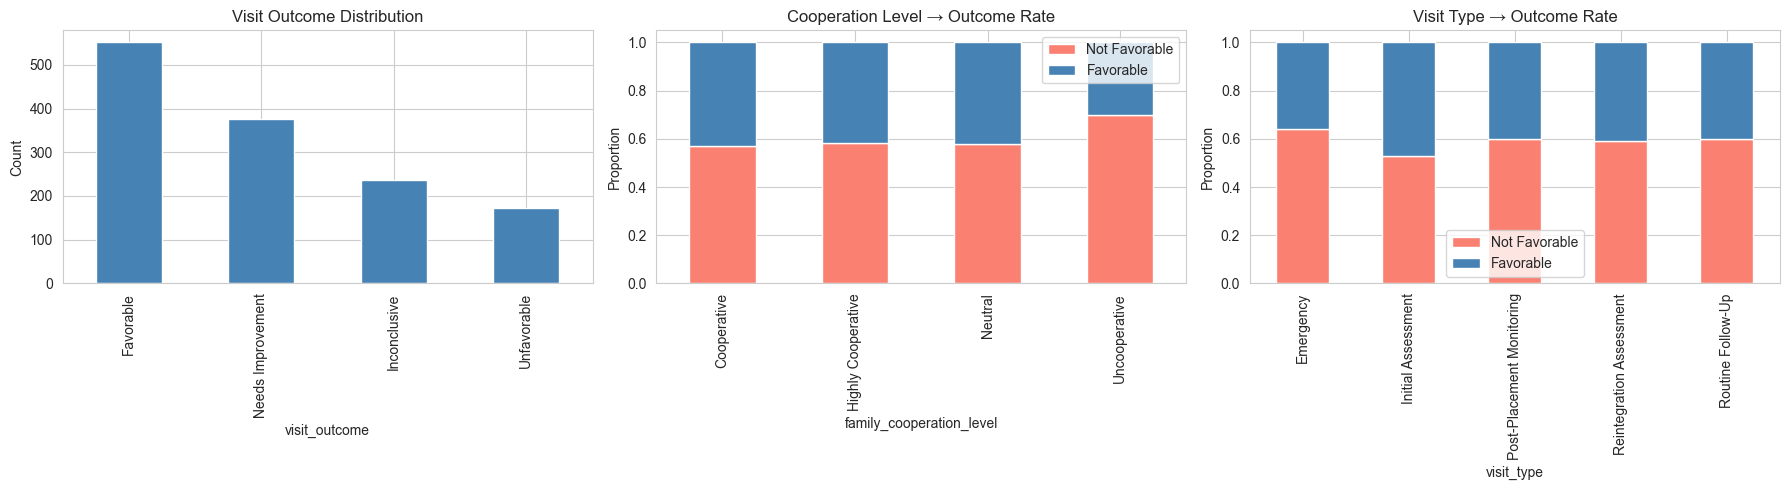

In [13]:
# ── EDA ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Outcome distribution
visits['visit_outcome'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Visit Outcome Distribution")
axes[0].set_ylabel("Count")

# Cooperation vs outcome
pd.crosstab(visits['family_cooperation_level'], visits['favorable'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1], color=['salmon', 'steelblue'], edgecolor='white')
axes[1].set_title("Cooperation Level → Outcome Rate")
axes[1].set_ylabel("Proportion")
axes[1].legend(['Not Favorable', 'Favorable'])

# Visit type vs outcome
pd.crosstab(visits['visit_type'], visits['favorable'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[2], color=['salmon', 'steelblue'], edgecolor='white')
axes[2].set_title("Visit Type → Outcome Rate")
axes[2].set_ylabel("Proportion")
axes[2].legend(['Not Favorable', 'Favorable'])

plt.tight_layout()
plt.show()

## 3. Modeling

### 3a. Explanatory Model — Logistic Regression (statsmodels)

In [14]:
import statsmodels.api as sm

# ── Prepare explanatory features ─────────────────────────────────────────────
feature_cols = ['coop_score', 'safety_flag', 'followup_flag', 'family_member_count',
                'prior_visit_count', 'days_since_last', 'prior_favorable_rate',
                'initial_risk_score', 'current_risk_score', 'abuse_type_count',
                'has_special_needs']

X_exp = df[feature_cols + ['visit_type', 'case_category']].copy()
X_exp = pd.get_dummies(X_exp, columns=['visit_type', 'case_category'], drop_first=True, dtype=int)
X_exp = X_exp.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
X_exp = sm.add_constant(X_exp)

y_exp = df['favorable']

try:
    logit = sm.Logit(y_exp, X_exp).fit(method='bfgs', maxiter=200, disp=0)
except Exception:
    logit = sm.Logit(y_exp, X_exp).fit_regularized(method='l1', alpha=0.1, disp=0)

print(logit.summary2())

# Odds ratios
odds = np.exp(logit.params).sort_values(ascending=False)
print("\nOdds Ratios (top 10):")
print(odds.head(10).round(3).to_string())

                                     Results: Logit
Model:                      Logit                   Pseudo R-squared:        0.496      
Dependent Variable:         favorable               AIC:                     950.7988   
Date:                       2026-04-10 02:57        BIC:                     1049.5643  
No. Observations:           1337                    Log-Likelihood:          -456.40    
Df Model:                   18                      LL-Null:                 -905.98    
Df Residuals:               1318                    LLR p-value:             2.3735e-179
Converged:                  1.0000                  Scale:                   1.0000     
Method:                     MLE                                                         
----------------------------------------------------------------------------------------
                                      Coef.   Std.Err.    z    P>|z|    [0.025   0.975] 
----------------------------------------------------------

### 3b. Predictive Model — Classifier Comparison

In [15]:
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

# ── Define features ──────────────────────────────────────────────────────────
numeric_cols = ['coop_score', 'safety_flag', 'followup_flag', 'family_member_count',
                'prior_visit_count', 'days_since_last', 'prior_favorable_rate',
                'initial_risk_score', 'current_risk_score', 'abuse_type_count', 'has_special_needs']
categorical_cols = ['visit_type', 'case_category']

y = df['favorable']
X = df[numeric_cols + categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      stratify=y, random_state=SEED)

# ── Preprocessing ────────────────────────────────────────────────────────────
numeric_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])
categorical_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
])

# ── Model comparison ─────────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}

candidates = [
    ("LogReg", LogisticRegression(max_iter=1000, random_state=SEED)),
    ("Decision Tree", DecisionTreeClassifier(max_depth=5, random_state=SEED)),
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=SEED)),
    ("Gradient Boosting", GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                                      learning_rate=0.1, random_state=SEED)),
]

rows = []
for name, estimator in candidates:
    pipe = Pipeline([("preprocess", preprocessor), ("model", estimator)])
    res = cross_validate(pipe, X_train, y_train, cv=skf, scoring=scoring, return_train_score=False)
    rows.append({
        "Model": name,
        "CV Accuracy": res["test_accuracy"].mean(),
        "CV F1": res["test_f1"].mean(),
        "CV AUC": res["test_roc_auc"].mean(),
    })

df_compare = pd.DataFrame(rows).sort_values("CV AUC", ascending=False)
print("Model comparison (5-fold CV on training set):")
print(df_compare.to_string(index=False))

Model comparison (5-fold CV on training set):
            Model  CV Accuracy    CV F1   CV AUC
           LogReg     0.825063 0.814343 0.882677
Gradient Boosting     0.807301 0.791900 0.869345
    Random Forest     0.805414 0.784984 0.867290
    Decision Tree     0.815704 0.803557 0.850184


## 4. Evaluation

Classification Report (Test Set):
               precision    recall  f1-score   support

Not Favorable       0.93      0.71      0.81       158
    Favorable       0.69      0.93      0.79       110

     accuracy                           0.80       268
    macro avg       0.81      0.82      0.80       268
 weighted avg       0.83      0.80      0.80       268

Test AUC: 0.8448


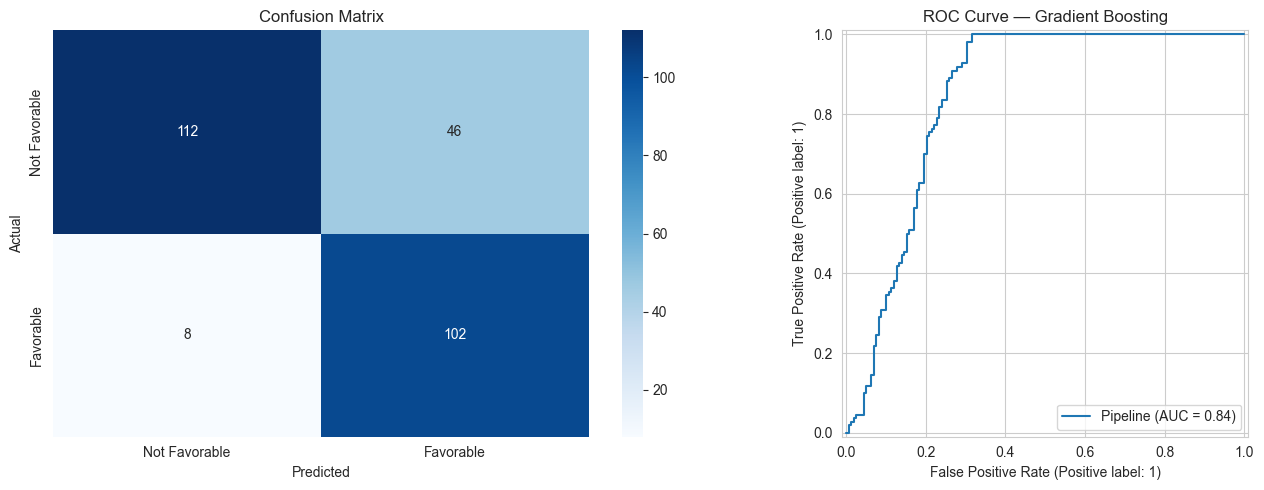

In [16]:
# ── Train best model & evaluate on test set ──────────────────────────────────
best_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                          learning_rate=0.1, random_state=SEED))
])
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=['Not Favorable', 'Favorable']))
print(f"Test AUC: {roc_auc_score(y_test, y_prob):.4f}")

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues', ax=axes[0],
            xticklabels=['Not Favorable', 'Favorable'],
            yticklabels=['Not Favorable', 'Favorable'])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC Curve — Gradient Boosting")
plt.tight_layout()
plt.show()

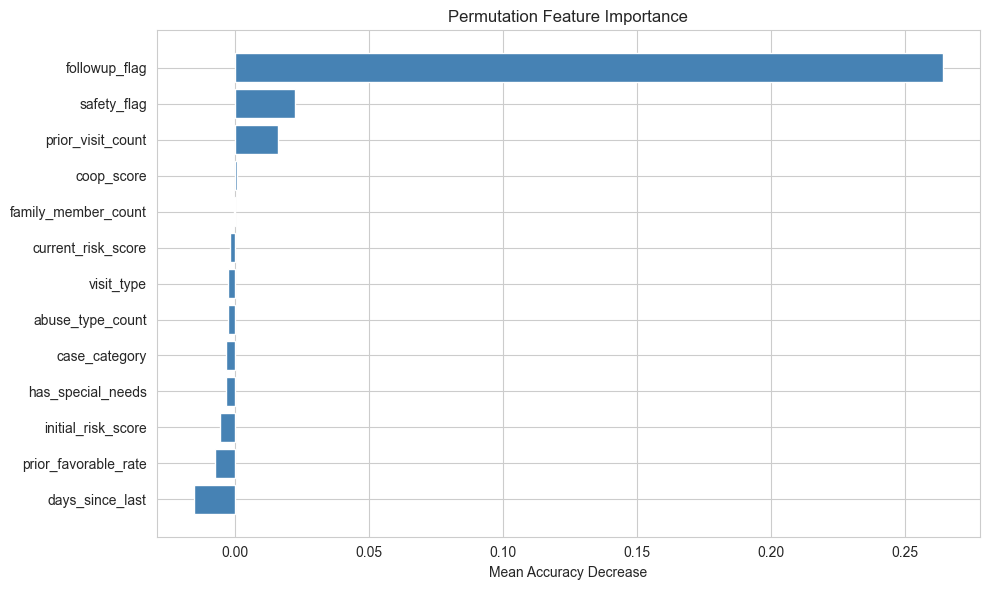

Top 5 features:
            Feature  Importance
      followup_flag    0.263930
        safety_flag    0.022637
  prior_visit_count    0.016294
         coop_score    0.000746
family_member_count   -0.000124


In [17]:
# ── Feature importance (permutation-based) ───────────────────────────────────
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(best_pipeline, X_test, y_test,
                                   n_repeats=30, random_state=SEED, scoring='accuracy')
# Permutation importance returns one value per INPUT feature
input_feature_names = numeric_cols + categorical_cols
imp_df = pd.DataFrame({
    'Feature': input_feature_names,
    'Importance': perm_imp.importances_mean
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='white')
ax.set_xlabel("Mean Accuracy Decrease")
ax.set_title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(imp_df.sort_values('Importance', ascending=False).head().to_string(index=False))

## 5. Causal and Relationship Analysis

**Important caveat:** This is an **observational** model. Visit outcomes depend on the social worker's judgment and resident cooperation — not random assignment. Positive coefficients on cooperation do not prove that *forcing* cooperation improves outcomes.

**Key findings:**
- **Cooperation level** is the strongest predictor — highly cooperative families are much more likely to have favorable visits
- **Safety concerns** being flagged reduces the odds of a favorable outcome
- **Prior favorable rate** (rolling history) signals residents with consistently positive trajectories
- **Visit type** matters: routine follow-ups have different outcome distributions than emergency visits

## 6. Deployment Notes (Ch. 17)

**Integration:** Visit outcome predictions are displayed on the **Home Visitation & Case Conferences** admin page. Before a scheduled visit, the model shows the predicted likelihood of a favorable outcome so social workers can prioritise follow-ups.

**Endpoint:** `POST /api/predict/visitation-outcome` — implemented in `Backend/Controllers/VisitationPredictorController.cs`, gated by `AuthPolicies.AdminOnly`.

**Deliberate C# reimplementation (Ch. 17 — model serving):**

Rather than shipping a pickled sklearn pipeline, the logistic-regression **coefficients** fit in this notebook (Section 3a) are hard-coded into the .NET controller and the logistic (`1 / (1 + exp(-z))`) is computed inline. Chapter 17 discusses this as a valid deployment pattern for small, stable linear models:

1. **No Python runtime in production.** The backend is .NET 10; embedding Python for inference would force an inter-process bridge and a second deployment artifact.
2. **Low-dimensional, interpretable model.** The Logit in Section 3a has ~18 coefficients — trivial to transcribe and audit. For a random forest or gradient booster we would instead serialise (joblib / ONNX).
3. **Reproducibility.** The coefficients committed in `VisitationPredictorController.cs` can be regenerated by re-running Section 3a; the notebook is the source of truth for feature encoding (cooperation map, risk map, one-hot dummies).
4. **Latency.** Inference is a handful of multiply-adds — sub-millisecond, suitable for on-demand display in the admin UI.

**How it works at request time:**
1. Frontend POSTs visit features (visit type, cooperation level, resident ID) to the endpoint
2. Controller looks up the resident's rolling `prior_favorable_rate` from the `HomeVisitations` table via EF Core
3. Features are encoded exactly as in this notebook (same cooperation map, same visit-type dummies)
4. The linear combination + sigmoid produces a favorable-outcome probability in `[0, 1]`
5. The React frontend displays a risk indicator on the visitation scheduling view

**Retraining cadence:** Re-run this notebook monthly as new visitation records accumulate, copy the updated coefficients into `VisitationPredictorController.cs`, and redeploy. If the coefficient structure ever changes (e.g. new feature added), both notebook and controller must be updated together.


## 7. Summary

| Model | Purpose | Key Result |
|-------|---------|------------|
| Logistic Regression (statsmodels) | Explain which factors drive favorable outcomes | Cooperation, safety concerns, visit history are significant |
| Gradient Boosting (sklearn) | Predict visit outcomes | Best CV AUC among candidates |

**Limitations:**
- Selection bias: social workers choose visit type and timing
- Outcome is a subjective assessment recorded by the social worker
- Model performance depends on cooperation level being known at prediction time

In [18]:
if conn is None:
    print('Skipped PipelineResults write (no DB connection).')
else:
    # ── Export to PipelineResults ─────────────────────────────────────────────────
    import json
    from datetime import datetime

    y_prob = best_pipeline.predict_proba(X)[:, 1]
    export_df = pd.DataFrame({
        'visitation_id': df['visitation_id'], 'score': y_prob.round(4),
        'label': ['Favorable' if p>=0.5 else 'Unfavorable' for p in y_prob]
    })

    cursor = conn.cursor()
    cursor.execute("DELETE FROM PipelineResults WHERE PipelineName = 'VisitationOutcome'")
    next_id = int(pd.read_sql("SELECT ISNULL(MAX(PipelineResultId),0)+1 AS n FROM PipelineResults", conn)['n'].iloc[0])

    for _, row in export_df.iterrows():
        cursor.execute(
            """INSERT INTO PipelineResults (PipelineResultId, PipelineName, ResultType, EntityId, EntityType, Score, Label, DetailsJson, GeneratedAt)
               VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s)""",
            (next_id, 'VisitationOutcome', 'Prediction', int(row['visitation_id']), 'HomeVisitation',
             float(row['score']), row['label'], None, datetime.utcnow()))
        next_id += 1

    conn.commit()
    print(f'Exported {len(export_df)} VisitationOutcome results to PipelineResults.')


IntegrityError: (2627, b"Violation of PRIMARY KEY constraint 'PK_PipelineResults'. Cannot insert duplicate key in object 'dbo.PipelineResults'. The duplicate key value is (5703).DB-Lib error message 20018, severity 14:\nGeneral SQL Server error: Check messages from the SQL Server\n")